# Decision Tree

## 1. Importing Necessary packages

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import GridSearchCV

## 2. Importing Dataset

In [3]:
claimants_data = pd.read_csv("claimants.csv")
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


## 3. Data Understanding

In [4]:
claimants_data.shape

(1340, 7)

In [6]:
claimants_data.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

In [7]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

## 4. Data Prepartion

### 4.1 Data Cleaning

In [8]:
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1335,34100,1,0.0,1.0,0.0,NaN,0.576
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [4]:
claimants_data.dropna(inplace=True)
claimants_data

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...,...,...
1334,34104,1,1.0,1.0,0.0,16.0,0.060
1336,34110,0,1.0,1.0,0.0,46.0,3.705
1337,34113,1,1.0,1.0,0.0,39.0,0.099
1338,34145,0,1.0,0.0,0.0,8.0,3.177


In [10]:
claimants_data.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [5]:
claimants_data.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

## 4.2 Separate Input and Output

In [13]:
# Input

In [6]:
X = claimants_data.drop(labels = ['CASENUM','ATTORNEY'],axis = 1)
X

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,0.0,1.0,0.0,50.0,34.940
1,1.0,0.0,0.0,18.0,0.891
2,0.0,1.0,0.0,5.0,0.330
3,0.0,1.0,1.0,31.0,0.037
4,0.0,1.0,0.0,30.0,0.038
...,...,...,...,...,...
1334,1.0,1.0,0.0,16.0,0.060
1336,1.0,1.0,0.0,46.0,3.705
1337,1.0,1.0,0.0,39.0,0.099
1338,1.0,0.0,0.0,8.0,3.177


In [15]:
# Output

In [7]:
y = claimants_data["ATTORNEY"]
y

0       0
1       1
2       1
3       0
4       1
       ..
1334    1
1336    0
1337    1
1338    0
1339    1
Name: ATTORNEY, Length: 1096, dtype: int64

## 5. Model building

In [1]:
# 5.1 Model Validation Techniques - Train Test Splot

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test , y_train, y_test = train_test_split(X,y, test_size= 0.20, shuffle= True, random_state=34)

In [9]:
# 5.2 K Fold Cross Validation

In [22]:
from sklearn.model_selection import KFold, cross_val_score
kfold = KFold(shuffle=True, random_state=123)
cv_score = cross_val_score(estimator=logistic_model, X = X, y = y, cv = kfold)
print(cv_score)
print("Overall Accuracy :",cv_score.mean().round(2))
print("Overall Accuracy :",cv_score.std().round(2))

[0.68636364 0.71232877 0.72146119 0.71689498 0.68949772]
Overall Accuracy : 0.71
Overall Accuracy : 0.01


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,shuffle=True, random_state= 45)

In [8]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
730,0.0,1.0,0.0,0.0,0.050
93,0.0,1.0,0.0,31.0,3.018
720,1.0,1.0,0.0,17.0,3.737
382,1.0,1.0,0.0,35.0,8.508
596,1.0,1.0,0.0,70.0,0.108
...,...,...,...,...,...
708,1.0,1.0,0.0,37.0,1.805
202,1.0,1.0,0.0,18.0,3.086
738,0.0,0.0,0.0,78.0,4.115
508,0.0,1.0,0.0,8.0,1.908


## 6. Model Training

In [12]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier, VotingClassifier

In [13]:
logistic_model = LogisticRegression()

In [17]:
rf_classifier = RandomForestClassifier(n_estimators= 75, max_depth= 5,criterion= 'entropy')

In [26]:
## Random Forest Classification

In [18]:
rf_classifier.fit(X_train,y_train)

,n_estimators,75
,criterion,'entropy'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [19]:
ada_boost_classifier = AdaBoostClassifier()
ada_boost_classifier.fit(X_train,y_train)

,estimator,None
,n_estimators,50
,learning_rate,1.0
,algorithm,'deprecated'
,random_state,None


In [20]:
logistic_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [21]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [22]:
dt_model = DecisionTreeClassifier(criterion= "gini",max_depth= 5)

### Stacking Technique

In [25]:
from sklearn.neighbors import KNeighborsClassifier

In [23]:
Logistic_classifier = LogisticRegression()

In [24]:
Decision_classifier = DecisionTreeClassifier()

In [26]:
Knn_classifier = KNeighborsClassifier()

In [28]:
voting_classifier = VotingClassifier(estimators= [("logistic_model",Logistic_classifier),("dt_model",Decision_classifier),("Knn_Model",Knn_classifier)])

In [31]:
voting_classifier.fit(X,y)

,estimators,"[('logistic_model', ...), ('dt_model', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [32]:
y_pred = voting_classifier.predict(X)

## Grid Search CV (Cross Validation)

In [12]:
from sklearn.model_selection import GridSearchCV

In [31]:
grid_search = GridSearchCV(estimator= rf_classifier, param_grid= {"max_depth":[5,6,7,8,9,10], "criterion":['gini','entropy'] ,"n_estimators":[50, 75, 100,150] } )
grid_search.fit(X,y)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 5, 'n_estimators': 100}
0.7317268576172686


In [15]:
grid_search = GridSearchCV(estimator= dt_model, param_grid= {"max_depth":[5,6,7,8,9,10], "criterion":['gini','entropy']} )
grid_search.fit(X_train,y_train)
print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'gini', 'max_depth': 5}
0.7180064935064936


In [17]:
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


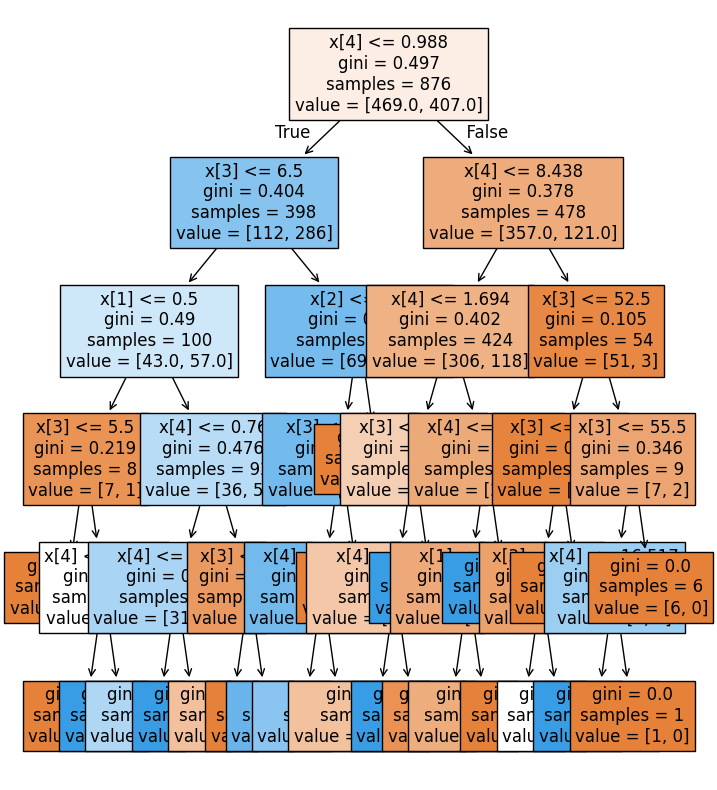

In [18]:
plt.figure(figsize=(8,10))
plot_tree(decision_tree = dt_model,fontsize=12,filled = True)
plt.show()

## 7. Model Testing

### Training Data

In [13]:
y_pred_train = rf_classifier.predict(X_train)
y_pred_train

array([1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0,

### Test Data

In [14]:
y_pred_test = rf_classifier.predict(X_test)
y_pred_test

array([1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1])

## 8. Model Evaluation

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, auc, roc_auc_score 

### 8.2 Train Data's Evaluation Metrics

In [16]:
print(confusion_matrix(y_train,y_pred_train))

[[368 101]
 [118 289]]


In [17]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.76      0.78      0.77       469
           1       0.74      0.71      0.73       407

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876



## ROC Curve - Receiver Operating Characteristics

### AUC - Area Under the curve

In [18]:
fpr, tpr, thresholds = roc_curve(y_train, rf_classifier.predict_proba (X_train) [:,-1])

In [19]:
auc = roc_auc_score(y_train,y_pred_train)
print(auc)

0.7473609488534861


Text(0, 0.5, 'True Positive Rate')

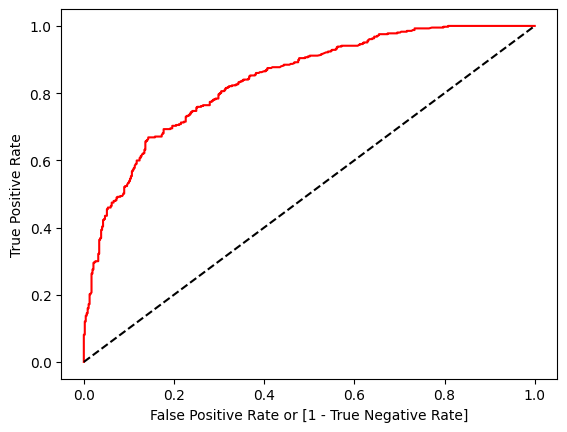

In [20]:
plt.plot(fpr, tpr, color= 'red', label = 'logic model(area = %0.2f)' %auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

## 8.3 Test Data's Evaluation Metrics

In [21]:
print(confusion_matrix(y_test,y_pred_test))

[[85 24]
 [40 71]]


In [22]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.68      0.78      0.73       109
           1       0.75      0.64      0.69       111

    accuracy                           0.71       220
   macro avg       0.71      0.71      0.71       220
weighted avg       0.71      0.71      0.71       220



## AUC and ROC Curve for Test Data

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, rf_classifier.predict_proba (X_test) [:,-1])

In [24]:
auc = roc_auc_score(y_test,y_pred_test)
print(auc)

0.7097280767005538


Text(0, 0.5, 'True Positive Rate')

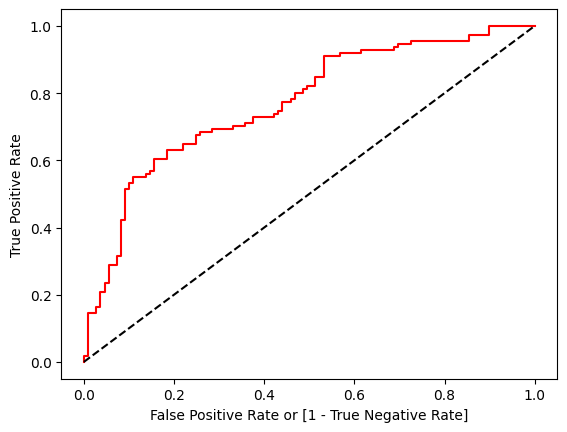

In [25]:
plt.plot(fpr, tpr, color= 'red', label = 'logic model(area = %0.2f)' %auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1 - True Negative Rate]')
plt.ylabel('True Positive Rate')

## 9. Model Deployment

In [34]:
from pickle import dump

In [35]:
dump(logistic_model,open("claimaints.pkl","wb"))